# 004: Grain Mapping DBSCAN

Written by Jean-Baptiste Jacob

Last updated: 20/02/2026

### Map grains by identifying cluster of pixels in orientation space
This is an alternative grain mapping method inspired from [Johnstone et al. (2020)](https://arxiv.org/abs/2001.02716), using density-based clustering (DBSCAN). The basic idea is that grains can be separated in orientation space by looking at clusters of pixels with similar orientations. We use here density-based clustering (DBSCAN) algorithm from scikit, but there are many different algorithms that can be used. This approach usually works well works as long as the orientation clusters formed by the different grains are well separated. In a large sample with many grains and large deformation, this becomes more challleging.  


**Main advantages** 
- easy to apply to 3D stacks (3D grain maps) or time series (grain evolution tracking)
- better than grain boundary thresholding for low resolution maps (large beam size compared to grain size)

**Main Limitations** 
- slow for large maps (> 100 kpx)
- does not work so well for complex samples with many grains and large deformation (orientation cluster overlaps)
- tuning clustering parameters can be a bit tedious (especially with many grains)
- there is no guarantee that pixels clusters correspond topologically to grains: They could belong ot disconnected domains in the maps.


For more robust grain mapping using some clustering approch, use MTex.

### load packages

In [4]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess


if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [5]:
# general modules
import os
import numpy as np
import matplotlib.pyplot as pl
from tqdm import tqdm

# ImageD11 + point-fit 3dxrd module
import ImageD11.grain
import ImageD11.columnfile
import ImageD11.sinograms.dataset


from pf3dxrd.pf3dxrd import utils, pixelmap, friedel_pairs, crystal_structure, peak_mapping

# orix
from orix import quaternion as oq, vector as ovec

# clustering
from sklearn.cluster import DBSCAN
import sklearn.metrics
from scipy.spatial import KDTree


%matplotlib ipympl
%load_ext autoreload
%autoreload 2

### Load data

This notebook has been written to process a z-stack of 2D maps (to map grains in 3D). However, it works as well if you just have one 2D map. Just put one element in `dslist`.

If multiple phases were indexed, the DBSCAN clustering procedure has to be run independently for each phase. The grain labels are then updated separately so that that grain index do not overlap between different phases. 

In [12]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3'
parfile= data_dir+'/SI3.par'

#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'
#parfile= data_dir+'/C18A_01.par'

# datasets list: list all datasets in the z-stack / time series
dslist = ['SI3_DT360Z5480'] 
#dslist = ['C18A_01_z180'] 

# phase list: all phases to map
phase_name_list = ['quartz','orthoclase','magnetite']
#phase_name_list = ['quartz', 'garnet']

In [51]:
def load_xmap(dsname):
    xmap_file = os.path.join(data_dir, f'{dsname}_xmap.h5')  
    xmap = pixelmap.load_from_hdf5(xmap_file)
    print(xmap)
    return xmap

def load_cf(dsname):
    peakfile = os.path.join(data_dir, f'{dsname}_pk2d_p_flt.h5')   
    dsfile = os.path.join(data_dir, f'{dsname}_dataset.h5')
    ds = ImageD11.sinograms.dataset.load(dsfile)
    
    cf = ImageD11.columnfile.columnfile(peakfile)
    cf.parameters.loadparameters(parfile)
    friedel_pairs.update_geometry_fpairs(cf, ds)

    if not cf.sortedby == 'xyi':
        print('sorting peakfile by "xyi"...')
        cf.sortby('xyi')
        
    return cf 

Load all data in a dictionnary containing all 2D maps from the stack. 

Several columns `features_[phase]` `mask_[phase]` and `ori_[phase]` are initialized at the same time. 

In [52]:
%%time
# dictionnary keys
###################
# dset: dataset name
# xmap: pixelmap
# features_[phasename]: normalized 4D space to perform clustering
# mask_[phasename]: mask to select pixels corresponding to the given phase on the map. 

keys = ['dset', 'xmap'] + [f'features_{p}' for p in phase_name_list] +\
                          [f'mask_{p}' for p in phase_name_list]     +\
                          [f'ori_{p}' for p in phase_name_list]

data = [[] for _ in range(len(keys))]
DATA_dict = dict(zip(keys,data))        
    
# load xmaps

for dsname in dslist:
    xmap = load_xmap(dsname)
    xmap.add_data(np.full(xmap.xyi.shape, -1, dtype=np.int16), 'grain_id')
    DATA_dict['dset'].append(dsname)
    DATA_dict['xmap'].append(xmap)

del data  
DATA_dict

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'GROD_angle', 'GROD_axis_xyz', 'KAM', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'gb_biotite', 'gb_magnetite', 'gb_misorientation_biotite', 'gb_misorientation_magnetite', 'gb_misorientation_oligoclase', 'gb_misorientation_orthoclase', 'gb_misorientation_quartz', 'gb_oligoclase', 'gb_orthoclase', 'gb_quartz', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 84
CPU times: user 850 ms, sys: 27.9 ms, total: 878 ms
Wall time: 421 ms


{'dset': ['SI3_DT360Z5480'],
 'xmap': [<pf3dxrd.pf3dxrd.pixelmap.Pixelmap at 0x12dd069b0980>],
 'features_quartz': [],
 'features_orthoclase': [],
 'features_magnetite': [],
 'mask_quartz': [],
 'mask_orthoclase': [],
 'mask_magnetite': [],
 'ori_quartz': [],
 'ori_orthoclase': [],
 'ori_magnetite': []}

For each phase, we need to define a feature space in which clustering will be performed. Here, we combine orientation dimensions using Euler angles and pixel coordinates $(x_i,y_i)$ in the sample. This helps in case the sample has many grains which partly overlap in orientation, but the position dimension can be muted if not needed (adding position sometimes makes clustering worse, especially complex microstructurers with weird grain shapes and large spread of grain size). 

This space needs to be normalized somehow, so that orientation and position coordinate show a similar spread. This is what the function `get_normalized_feature_space` below does. The coordinates of each point in this feature space is  then added to to DATA_dict.

In [53]:
def get_normalized_feature_space(xmap, pname):
    """ select orientation from xmap and return normalized feature space built using symetry-reduced orientations 
    (in euler angles) and (x,y) position: (eul1, eul2, xi, yi). Each dimension is rescaled to values between 0 and 1
    
    return:
    features: 4D array of values to perform clustering
    cs: corresponding crystal phase
    mask : phase mask for pixels in xmap
    """
    # phase structure, mask and symmetry
    cs = xmap.phases.get(pname)
    uc = ImageD11.unitcell.unitcell(cs.cell, symmetry=cs.spg_no)
    msk = xmap.get_phase_mask(pname)
    sym = cs.orix_phase.point_group.laue
    # orientation in symmetry reduced zone: first in quaternion (default in orix) and then in Euler angles
    ori_quat = uc.get_orix_orien_fast(xmap.U[msk])
    ori_quat = ori_quat.map_into_symmetry_reduced_zone()
    ori_euler = ori_quat.to_euler(degrees=True)
    xi, yi = xmap.xi[msk], xmap.yi[msk]
    
    #  rescale to [0,1] along each dimension
    d1 = ori_euler[:,0] / 360
    d2 = ori_euler[:,1] / 90
    d3 = (xi - xi.min()) / (xi.max() - xi.min())
    d4 = (yi - yi.min()) / (yi.max() - yi.min())
    
    return ori_quat, np.array([d1,d2,d3,d4]).T, cs, msk


In [56]:
# compute feature space and update DATA_dcit for each phase

for pname in phase_name_list:
    for xmap in DATA_dict['xmap']:
        ori, features, cs, msk = get_normalized_feature_space(xmap, pname)
        DATA_dict[f'mask_{pname}'].append(msk)
        DATA_dict[f'features_{pname}'].append(features)
        DATA_dict[f'ori_{pname}'].append(ori)

# print updated dictionnary to check it is ok
# xmap size and mask_phase should have the same shape
# feature_phase shape should be (N,4) or (N,2) with N <= xmap size

for i, dset in enumerate(DATA_dict['dset']):
    print(f'Dataset {dset}\n-----------------------')
    for k,v in DATA_dict.items():
        if 'xmap' in k:
            print(f'{k} size: {v[i].xyi.shape}')
        if any(['features' in k, 'mask' in k]):
            print(f'{k}:{v[i].shape}')
            
    print('=========================')

Dataset SI3_DT360Z5480
-----------------------
xmap size: (12100,)
features_quartz:(1330, 4)
features_orthoclase:(795, 4)
features_magnetite:(73, 4)
mask_quartz:(12100,)
mask_orthoclase:(12100,)
mask_magnetite:(12100,)


Concatenate all features arrays in the stack into one big array for each phase. This will allow to do clustering in 3D instead of doing it slice by slice (ie. directly identify grains clusters in 3D)

In [57]:
stacked_features = {pname:_ for pname in phase_name_list}

for pname in phase_name_list:
    stacked_features[pname] = np.concatenate([ft for ft in DATA_dict[f'features_{pname}']])
    print(f'All datasets - {pname}: {stacked_features[pname].shape}')

All datasets - quartz: (2660, 4)
All datasets - orthoclase: (1590, 4)
All datasets - magnetite: (146, 4)


### DBSCAN Clustering

Now that each pixel has been assigned coordinates in a feature space, we can run DBSCAN clustering. 

#### Parameters for DBSCAN: eps and min_samples
DBSCAN has two parameters to adjust: `eps` and `min_sample`

- `eps ` controls the maximum distance between two points for one to be considered as in the neighborhood of the other. This is the most important parameter.
- `min_samples` controls the number of points in a neighborhood for a point to be considered as a core point. Higher values will identify denser clusters, while lower values will identify more sparse clusters.

#### cluster using a subset
For large maps, the number of pixels to cluster can be very large (>1M. This is a problem because DBSCAN does not scale up very well, resulting in long computation time and large memory consumption. To avoid this, it is possible to take a subset of data points, and map each point in the full dataset to its closests neighbour in the subset (in feature space) using a KDTree. Then, clustering is done on the subset, and cluster labels found in the subset are mapped to the full set of pixels. 

To use this method, set `use_subset = True` in `fit_dbscan`. The downsampling_factor is an integer controling the size of the subset. If downsampling_factor = n, len(data_subset) ~ len(data) / n

In [18]:
def fit_dbscan(data, eps=0.5, min_samples=5, use_subset=False, downsampling_factor = 2):
    # define model
    model = DBSCAN(eps = eps, min_samples = min_samples)
    
    # select data to cluster: either full data or a subset
    if use_subset:
        data_to_fit = data[::downsampling_factor]
    else: 
        data_to_fit = data
    
    # cluster data
    labels = model.fit_predict(data_to_fit)
    clst, clst_size = np.unique(labels, return_counts=True)
    
    # cluster centroids (for labels != -1, which corresponds to data not assigned to any cluster)
    clst_cs = []
    for i in clst:
        if i == -1:
            continue
        cen = np.median(data_to_fit[labels == i], axis=0)
        clst_cs.append(cen)
    clst_cs = np.array(clst_cs)
    
    # Map full data to nearest subset points (if subset is used)
    if use_subset:
        kd_tree = KDTree(data_to_fit)
        _, nearest_indices = kd_tree.query(data, k=1)
        labels_all = labels[nearest_indices.flatten()]
    else:
        labels_all = labels
    
    return labels_all, clst, clst_size, clst_cs


def performance_metrics(data, labels):
    """ Evaluate the clustering performance using various criteria"""
    ncl = len(np.unique(labels)) - 1
    
    # completeness : prportion of points assigned to a cluster
    completeness = np.count_nonzero(labels != -1)/len(labels) 
    
    #  Mean Silhouette Coeff. Calculated using the mean intra-cluster distance and the mean nearest-cluster distance
    # ranges from 1 (best) to -1 (worst). ~0 : overlapping clusters. <0 : probably wrong cluster assignment
    silhouette = sklearn.metrics.silhouette_score(data, labels, sample_size=10000)
    
    # Davies-Bouldin score: average similarity measure of each cluster with its most similar cluster
    #clusters which are farther apart and less dispersed will result in a better score. The minimum score is zero,
    # with lower values indicating better clustering.
    dbi = sklearn.metrics.davies_bouldin_score(data, labels)
    
    # Variance Ratio Criterion (Calinski and Harabasz score): ratio of the sum of between-cluster dispersion and of
    # within-cluster dispersion. Higher value indicate better clustering, because it means that the data points are
    # more spread out between clusters than they are within clusters. 
    vrc = sklearn.metrics.calinski_harabasz_score(data, labels)
    
    titles = 'N clusters,Completeness,Mean Silhouette Coeff,Davies-Bouldin Score,Variance Ratio Criterion'.split(',')
    stats = [ncl, completeness, silhouette, dbi, vrc]
    performance_stats = {t:arr for t,arr in zip(titles,stats)}
    
    return performance_stats


#### Adjust DBSCAN parameters 

In order to find the best values eps and min_sample, we can try to vary these values and evaluate clustering performance for each value. A series of metrics are then defined in sklearn to evaluate the quality of clustering. Read comments in performance_metrics above, or find the documentation of these functions in sklearn.metrics for more details. 

Work with each phase separately. For each one, do clustering and compute performance metric over a range of eps values (min samples is usually less critical, but it can be varied as well).  

In [88]:
# try different values of eps and min_sample in DBSCAN and evaluate performance.
# For SI3_DT360Z5480, downsampling is not needed since the map is pretty small.

phase = 'garnet'
use_xy_pos = False  # set to True if you want to perform clustering inclusing (xi,yi) pixel coordinates in the features

# define array of eps. Use a wide range first, to see how the performance metrics behave 
eps = np.linspace(0.005,0.05,20)
min_samples = 5

titles = 'N clusters,Completeness,Mean Silhouette Coeff,Davies-Bouldin Score,Variance Ratio Criterion'.split(',')
stats_all = {t:[] for t in titles}


for e in tqdm(eps):
    # find clusters for data subset
    if use_xy_pos:
        data = stacked_features[phase]
    else:
        data = stacked_features[phase][:,:2]
        
    labels, clst, clst_size, clst_cs = fit_dbscan(data, e, min_samples, use_subset=False)

    # compute performance stats
    try:
        stats = performance_metrics(data, labels)
        for s_all,s_i in zip(stats_all.values(), stats.values()):
            s_all.append(s_i)
        
    except:
        for s_all in stats_all.values():
            s_all.append(np.nan)

vcr = 'Variance Ratio Criterion'
stats_all[vcr] = np.array(stats_all[vcr]) / np.nanmax(stats_all[vcr])

100%|██████████| 20/20 [00:20<00:00,  1.05s/it]


Now we can plot performance metrics vs eps. and  vs. N_clusters

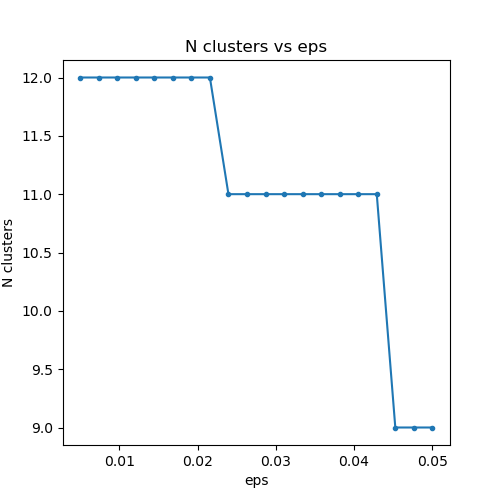

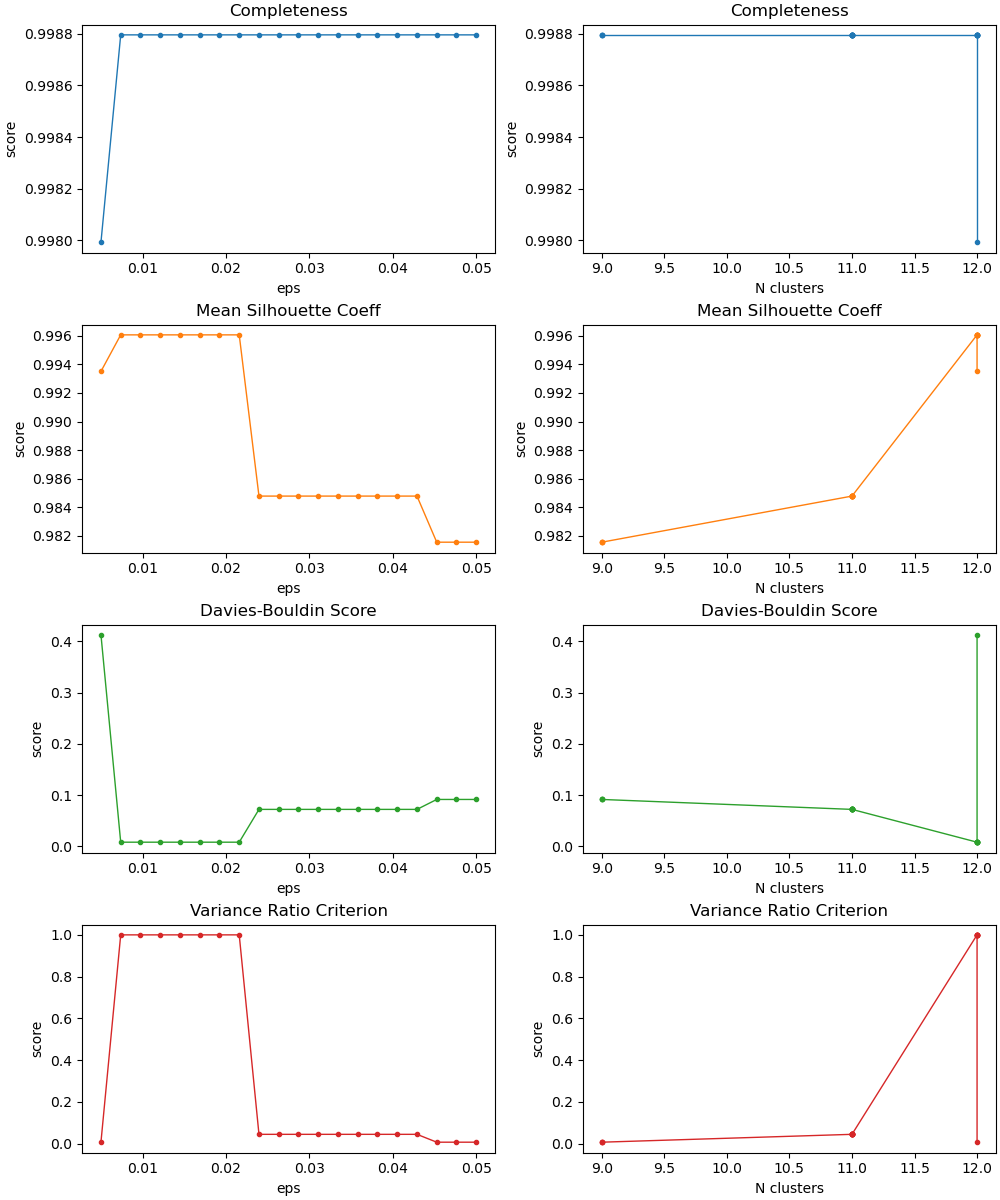

In [11]:
# plot performance index
nrow = len(stats_all) - 1
colors = pl.matplotlib.cm.tab10.colors


pl.figure(figsize=(5,5))
pl.plot(eps, stats_all['N clusters'], '.-')
pl.xlabel('eps')
pl.ylabel('N clusters')
pl.title('N clusters vs eps')

fig, ax = pl.subplots(nrow,2, figsize=(10,3*nrow), layout='constrained')

for i, (t,v) in enumerate(stats_all.items()):
    i = i-1
    if t == 'N clusters':
        continue
    color= colors[i]
    ax[i,0].plot(eps, v, '.-', lw=1., color = color)
    ax[i,0].set_xlabel('eps')
    ax[i,0].set_ylabel('score')
    ax[i,0].set_title(t)
    
    ax[i,1].plot(stats_all['N clusters'], v, '.-', lw=1., color=color)
    ax[i,1].set_xlabel('N clusters')
    ax[i,1].set_ylabel('score')
    ax[i,1].set_title(t)
    
    

#### N_clusters vs. eps

The number of clusters found broadly decreases with increasing eps. This is expected, since eps controls the maximum distance between points in a neighborhood. Larger eps thus returns larger clusters with larger distance between points, while lower eps will identify smaller, more closely grouped clusters. 

#### performace metrics vs. eps / N_cluster
Optimal eps should correspond to highest completeness, variance ratio criterion, silhouette coefficient, and lowest davies-bouldin score. For quartz in SI3_DT360Z5480, there is a significant drop of these statistics below eps = 0.05 (N_cluster > 38) and above eps = 0.2 (N_clusters < 30). The number of optimal clusters seems to be around 35, for eps ~ 0.15. 


The same procedure need sot be done separately for each phase,because optimal clustering parameters are not necessarilty the same. For small grain number, just plot the ipf map to check hw many grains to expect. For large maps with many grains this becomes impractical, so you have to "trust" the metrics. 

#### Find grains
Once optimal clustering parameters have been adjusted for all phases, perform DBSCAN clustering sequentially. Enter adjusted eps and min_sample for eahc phase below, and run the cell
Outputs are stored in two dictionnaries: grain_labels dict contains cluster labels (grain index) for each pixel, and clusters dict contains label, centroid and size of each cluster.

In [58]:
# clustering params for each phase in stacked_features
eps_list = [0.015, 0.015, 0.015]
min_samples_list = [5, 5, 5]
use_xy_pos = False

# initialize dict of results
grain_labels = {p:[] for p in stacked_features}
clusters     = {p:[] for p in stacked_features}

# Clustering: return a grain label for each data point, first in data subset and then in full data
for p,eps,ms in zip(stacked_features, eps_list, min_samples_list):
    if use_xy_pos:
        data = stacked_features[p]
    else:
        data = stacked_features[p][:,:2]
    
    # find clusters in data subset with dbscan
    labels, clst_ids, clst_size, clst_cs = fit_dbscan(data, eps, ms, use_subset=False)
    
    grain_labels[p] = labels
    clusters[p] = [clst_ids, clst_size, clst_cs]
    print(f'{p} pixels clustering completed. Found {len(clst_ids)-1} unique grains.')
    
    
# We do not want grains from different phases to have the same grain label. Thus we need to update the results so that each phase has its 
# unique set of grain labels
print('===================================')
print('unique grain labels\n----------------------------')
for i, (p, labs) in enumerate(grain_labels.items()):
    
    clst_labs = clusters[p][0]
    
    # for the first phase in grain labels dict, do not change anything
    if i == 0:
        labels_unique = np.unique(labs)
    # for other phases, update labels whenever they are > -1 (-1 stands for non-labeled outliers)
    else:
        labs = np.where(labs == -1, -1, labs + max(labels_unique) + 1)
        clst_labs = np.where(clst_labs == -1, -1, clst_labs + max(labels_unique) + 1)
        labels_unique = np.concatenate((labels_unique,np.unique(labs)))
        grain_labels[p] = labs
        clusters[p][0] = clst_labs
        
        
    # print outputs
    print(f'{p}:\n{np.unique(labs)}\n-----------------------')
    

quartz pixels clustering completed. Found 37 unique grains.
orthoclase pixels clustering completed. Found 49 unique grains.
magnetite pixels clustering completed. Found 8 unique grains.
unique grain labels
----------------------------
quartz:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36]
-----------------------
orthoclase:
[-1 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85]
-----------------------
magnetite:
[-1 86 87 88 89 90 91 92 93]
-----------------------


#### Plots
Make some plots to check grain identification is ok:
- pixels colored by cluster_id in symmetry-reduced orientation space. **points in a same cluster should have the same color**
- scatter plot of cluster centroids over ipf color map for each phase. Dot color (within the white circle) is determined from the mean orientation of the cluster, using the same color key as the ipf map. Therefore, **the color of each dot should be the same as the color of the corresponding grain**. Plotted only if clustering has been done in 4-dimension space including sample coordinates. 


Check that:
- all points within a cluster have the same color (fig1)
- there are no black clusters (unlabeled points). You can also check the completeness index in performance_stats, which measures the proportion of labeled points over the total number of points. 
- grain centroids plot in the center of grains (fig.2) and have the same ipf color (ie similar orientation). 

In [59]:
# plotting functions

def get_subset_orientations(pname):
    """ return all orientations for the data subset, mapped into the symmetry_reduced zone, for phase pname"""
    # select data
    cs = xmap.phases.get(pname)
    ori_arr = np.concatenate([o.data for o in DATA_dict[f'ori_{pname}']])  # stacked orientations from all maps
    ori_stacked = oq.Orientation(ori_arr, symmetry=cs.orix_phase.point_group.laue)
    ori_stacked.map_into_symmetry_reduced_zone()
    
    return ori_stacked


def get_cluster_orientations(pname):
    """ 
    return mean orientation for all clusters mapped into the symmetry-reduced zone, for phase pname
    """
    cs = xmap.phases.get(pname)
    ori = get_subset_orientations(pname)  # pixel orientation
    
    clst_ids, clst_size, clst_cs = clusters[pname]  # cluster properties: id, size, centroid
    labels = grain_labels[pname]                    # pixel labels in data subset
                          
    # mean cluster orientation
    q_mean = [ori[labels == l].mean() for l in clst_ids[clst_ids > -1]]
    ori_clusters = oq.Orientation.stack(q_mean).flatten()
    ori_clusters.symmetry = ori.symmetry
    ori_clusters.map_into_symmetry_reduced_zone()
    
    return ori_clusters



def make_ipf_plots(pname, save=False):
    """ 
    plot pixel orientation in inverse pole figure space 
    + make scatter plot of cluster centroids overlapped with ipf color map from xmap
    
    pname : phase name 
    cluster_size_factor: adjust spot size for clusters in scatter plot
    ipf_direction: reference direction ofr the inverse pole figure. z-axis = [0,0,1] (default)
    save (bool): save plot
    """
    # extract data
    ##################
    cs = xmap.phases.get(pname)
    cs.get_ipfkey()
    labels = grain_labels[pname]
    clst_ids, clst_size, clst_cs = clusters[pname]
    # pixel orientations
    ori = get_subset_orientations(pname)
    # cluster orientations
    clst_ori = get_cluster_orientations(pname)
    clst_rgb = cs.ipfkey.orientation2color(clst_ori)  # color for plotting
    
    # IPF maps
    ###################    
    oref = ovec.Vector3d.zvector()
    kw_subplot = {'projection':'ipf', 'symmetry':cs.orix_phase.point_group.laue, 'direction':oref}
    kw_density = {'cmap':'Reds', 'log':True, 'resolution':.5, 'sigma':.5}

    # fig1 : scatter plot in inverse pole figure space
    fig1 = pl.figure(figsize=(10,5))
    ax1 = fig1.add_subplot(121, **kw_subplot)
    ax2 = fig1.add_subplot(122, **kw_subplot)

    ax1.scatter(ori, s=2., c = labels, cmap = cmap, vmin=-1, alpha=.3)  # all data point colored by labels
    ax2.pole_density_function(ori * oref, **kw_density)                 # ipf density map
    fig1.suptitle(f'{pname} clusters')

    # fig2: ipf color map with cluster centroids: only if sample (xi,yi) coords in featuree space 
    if clst_cs.shape[-1] < 4:
        return
    # rescale cluster centroids to match with xmap coordinates
    msk = xmap.get_phase_mask(pname)
    xi, yi = xmap.xi[msk], xmap.yi[msk]
   
    csx = clst_cs[:,2] * (xi.max() - xi.min()) + xi.min() 
    csy = clst_cs[:,3] * (yi.max() - yi.min()) + yi.min() 

    # plot ipf color map for x,y,z axis
    fig2 = xmap.plot_ipf_orientation(pname, ipf_directions='xyz', smooth=False, out=True)
    for i, ax in enumerate(fig2.axes):
        # add cluster centroids ot each map
        cs.get_ipfkey(direction = ovec.Vector3d(np.eye(3,3)[i]))
        clst_rgb = cs.ipfkey.orientation2color(clst_ori) 
        ax.scatter(csx, csy, s=50, c=clst_rgb, edgecolors='r', lw=1)

           

In [60]:
# define colormap for clusters
Ncolors = labels_unique.max() + 1
cmap = utils.random_color_map(Ncolors)

/cvmfs/hpc.esrf.fr/software/packages/linux/x86_64/jupyter-slurm/2025.04.5/envs/jupyter-slurm/lib/python3.12/site-packages/orix/measure/pole_density_function.py:222: RuntimeWarning: divide by zero encountered in log
  hist = np.log(hist + 1)


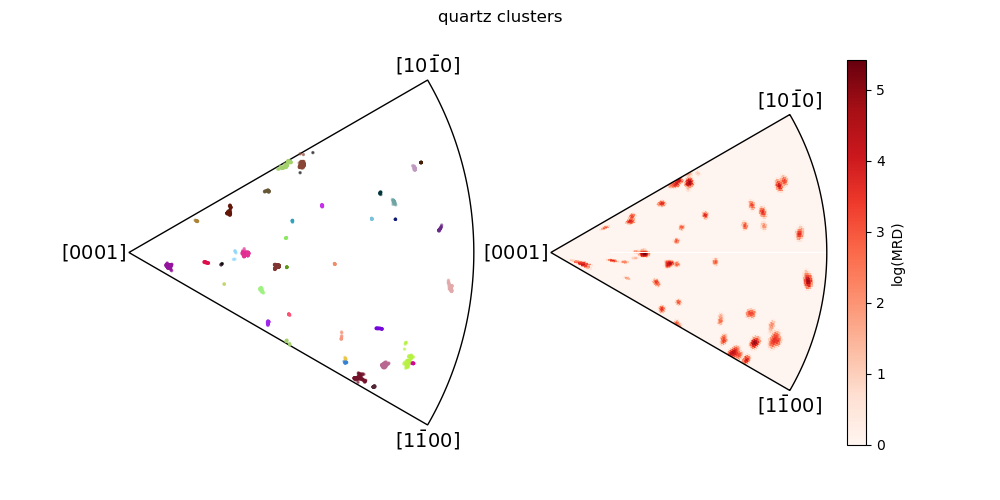

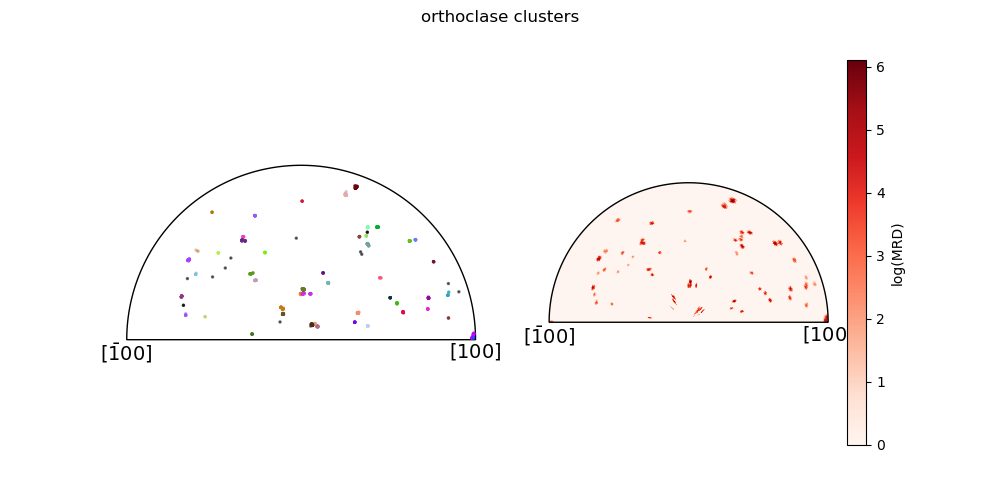

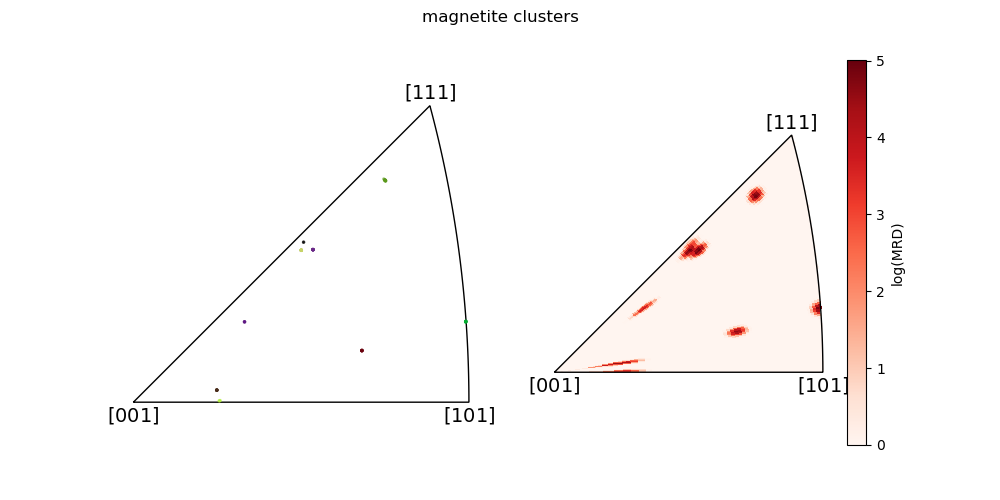

In [61]:
# plots in inverse pole figure space
for pname in phase_name_list:
    make_ipf_plots(pname, save=False)

### Add grain labels to xmaps
extract labels stored in grain_labels dict and update grain_id columns in all 2D pixelmaps in DATA_dict

In [62]:
def add_grain_labels_to_xmaps(pname):
    
    labels_all = grain_labels[pname]    # all labels in 3D stack     
    
    # index positions to split grain_labels[pname] by 2D slices
    inds = [0]
    for f in DATA_dict[f'features_{pname}']:
        inds.append(inds[-1] + len(f) )
    
    # loop through 2D map stack
    print(f'Adding labels to xmaps for phase {pname}')
    for i, (xmap, msk) in tqdm( enumerate(zip(DATA_dict['xmap'], DATA_dict[f'mask_{pname}'])) ):
        # extract labels corresponding to the 2D slice
        labels_slice2D = labels_all[inds[i]:inds[i+1]]
        assert len(labels_slice2D) == np.count_nonzero(msk), 'labels shape does not match with phase mask' # sanity check
        
        # update grain_id labels in xmap
        xmap.update_pixels('grain_id', labels_slice2D, selection_mask=msk)
        

In [63]:
for pname in phase_name_list:
    add_grain_labels_to_xmaps(pname)

Adding labels to xmaps for phase quartz


1it [00:00, 1539.76it/s]


Adding labels to xmaps for phase orthoclase


1it [00:00, 995.09it/s]


Adding labels to xmaps for phase magnetite


1it [00:00, 5184.55it/s]


Plot grain_id in each xmap to check grain maps are ok

In [64]:
# check grain labels have been added in xmap.grain_id

In [65]:
for xmap in DATA_dict['xmap']:
    print(np.unique(xmap.grain_id))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70
 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93]


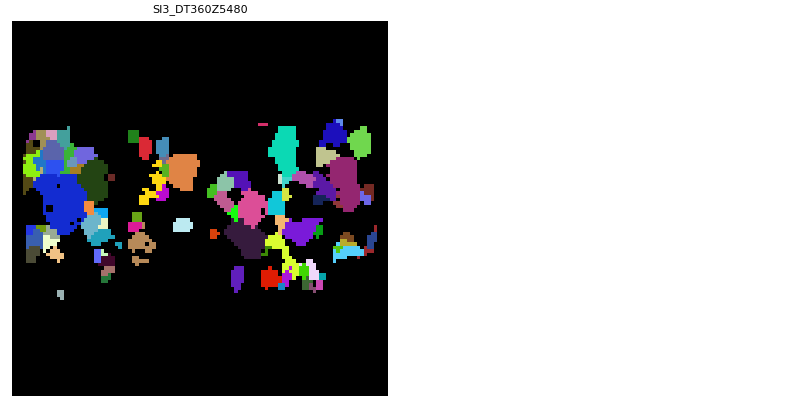

In [66]:
# plot grain_id for each map. Each grain is assigned a random color based on grain_id value
cmap = utils.random_color_map(ncolors=len(labels_unique))

kw = {'cmap':cmap, 'vmin':0, 'vmax':labels_unique.max()}
ncol = 2
nrow = np.ceil(len(DATA_dict['xmap'])/ncol).astype(int)

# grid
xmap = DATA_dict['xmap'][0]
nx, ny = xmap.grid.nx, xmap.grid.ny
xb, yb = xmap.grid.xbins, xmap.grid.ybins


pl.close('all')
fig, ax = pl.subplots(nrow, ncol, figsize=(4*ncol,4*nrow), layout = 'constrained')
ax = ax.ravel()
for a in ax:
    a.set_axis_off()
    a.set_aspect('equal')

for a,x,d in zip(ax, DATA_dict['xmap'], DATA_dict['dset']):
    #m = xmap.phase_id == xmap.phases.orthoclase.phase_id
    m = xmap.phase_id != -1
    gid = np.where(m, xmap.grain_id,-1)
    a.pcolormesh(xb,yb,gid.reshape(nx,ny), **kw)
    a.set_title(d, fontsize=8)
    

#fig.savefig(os.path.join(data_dir, dset, f'{sample}_grain_map.png'), format='png')

In [67]:
xmap.grains.__init__()
print(xmap)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'GROD_angle', 'GROD_axis_xyz', 'KAM', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'gb_biotite', 'gb_magnetite', 'gb_misorientation_biotite', 'gb_misorientation_magnetite', 'gb_misorientation_oligoclase', 'gb_misorientation_orthoclase', 'gb_misorientation_quartz', 'gb_oligoclase', 'gb_orthoclase', 'gb_quartz', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 0


If we print xmap, we see that it still has no grain assigned in xmap.grains. They can be added from the grain_id column,  using the add_grain_from_mask method. This function selects subsets of pixels based on grain_id value and computes a "mean" unit cell matrix for each subset, which is then exported as an ImageD11.grain object and added to xmap.grains. 

In [68]:
for x,d in (zip(DATA_dict['xmap'], DATA_dict['dset'])):
    # loop through all phases
    for i, p in enumerate(phase_name_list):
        if i == 0:
            x.add_grains_from_map(p, overwrite=True)
        else:
            x.add_grains_from_map(p, overwrite=False)
            
print(xmap)

100%|██████████| 9/9 [00:00<00:00, 22.68it/s]

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'GROD_angle', 'GROD_axis_xyz', 'KAM', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'gb_biotite', 'gb_magnetite', 'gb_misorientation_biotite', 'gb_misorientation_magnetite', 'gb_misorientation_oligoclase', 'gb_misorientation_orthoclase', 'gb_misorientation_quartz', 'gb_oligoclase', 'gb_orthoclase', 'gb_quartz', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 94


Now we see that the number of grains matches with the labels in np.unique(xmap.grain_id). xmap.grains contains a dictionnary of grains, with keys corresponding to the grain id. 

In [69]:
xmap.grains.dict

{0: <ImageD11.grain.grain at 0x12dd0634eba0>,
 1: <ImageD11.grain.grain at 0x12dd06536e10>,
 2: <ImageD11.grain.grain at 0x12dd069bc3e0>,
 3: <ImageD11.grain.grain at 0x12dd063c3410>,
 4: <ImageD11.grain.grain at 0x12dd06262ae0>,
 5: <ImageD11.grain.grain at 0x12dd06386270>,
 6: <ImageD11.grain.grain at 0x12dd06395520>,
 7: <ImageD11.grain.grain at 0x12dd063c2090>,
 8: <ImageD11.grain.grain at 0x12dd0640c200>,
 9: <ImageD11.grain.grain at 0x12dd061fce60>,
 10: <ImageD11.grain.grain at 0x12dd06525550>,
 11: <ImageD11.grain.grain at 0x12dd0633abd0>,
 12: <ImageD11.grain.grain at 0x12dd068302c0>,
 13: <ImageD11.grain.grain at 0x12dd069b3ce0>,
 14: <ImageD11.grain.grain at 0x12dd062113a0>,
 15: <ImageD11.grain.grain at 0x12dd06832270>,
 16: <ImageD11.grain.grain at 0x12dd0681d610>,
 17: <ImageD11.grain.grain at 0x12dd06280e00>,
 18: <ImageD11.grain.grain at 0x12dd069b20c0>,
 19: <ImageD11.grain.grain at 0x12dd06394c20>,
 20: <ImageD11.grain.grain at 0x12dd0629ddf0>,
 21: <ImageD11.grain.gr

Now we can save the pixelmaps. The grains dict will also be saved as a separate group in the h5 file. 

In [31]:
# add grains to xmap.grains and save maps
for xmap in DATA_dict['xmap']:    
    xmap.save_to_hdf5()

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.h5


### Grain refinement
Refine grains `UBI` using peaks assigned ot each grain (same as Tuto_004_Grain_Mapping with thresholding method)

1) assign peaks in peakfile to grains in pixelmap based on grain masks
2) for each grain, select peaks from the peakfile, exclude outliers and merge by unique hkl
3) fit new grain UBI using the merged g-vectors, using a similar procedure as pixel-by-pixel indexing

In [70]:
# add peakfiles to Data dict
DATA_dict['cf'] = []
    
for dsname in dslist:
    cf = load_cf(dsname)
    DATA_dict['cf'].append(cf)

Reading your columnfile in hdf format
sorting peakfile by friedel pair index...
sorting peakfile by "xyi"...


In [71]:
cf.nrows

1123896

Now we can use the function map_pks_to_grains to map each peak in the peakfile to a grain in xmap.grains. This function updates the grain_id column in the peakfile and adds a property pksindx to each grain, which corresponds to the index position of peaks assigned to this grain in the peakfile.

In [75]:
# map grains to peakfiles
for xmap, cf in zip(DATA_dict['xmap'], DATA_dict['cf']):
    for i, p in enumerate(phase_name_list): 
        if i == 0:
            xmap.map_pks_to_grains(p, cf, overwrite=True)
        else:
            xmap.map_pks_to_grains(p, cf, overwrite=False)
cf.filter(cf.grain_id != -1)

peaks to grains mapping...


100%|██████████| 37/37 [00:00<00:00, 1753.41it/s]


completed
peaks to grains mapping...


100%|██████████| 49/49 [00:00<00:00, 2144.51it/s]


completed
peaks to grains mapping...


100%|██████████| 8/8 [00:00<00:00, 2137.77it/s]

completed


We can check grain index in peakfiles and xmaps, to make sure they all match

In [78]:
def check_grain_labels(cf, xmap):
    # check grain labels are consistent in xmap.grain_id, xmap.grains and peakfile
    gids_xmap = np.unique(xmap.grain_id)
    gids_glist = np.array(xmap.grains.gids)
    gids_cf = np.unique(cf.grain_id)

    assert np.all(np.equal(gids_xmap[1:], gids_glist)), 'grain labels in xmap.grain_id and xmap.grains do not match'
    assert np.all(np.equal(gids_xmap[1:], gids_cf)), 'grain labels in xmap and peakfile do not match'
    
    print('grain labels OK')
    
for xmap,cf in zip(DATA_dict['xmap'], DATA_dict['cf']):
    check_grain_labels(cf, xmap)

[(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83,
       84, 85, 86, 87, 88, 89, 90, 91, 92, 93], dtype=int16), '\n', (95,)), (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93], dtype=int16), '\n', (94,)), (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 

Now we can refine each grain `UBI` using all peaks assigned from the grain mask. 

**Notes**
- use large hkl tolerance here, because we want the "average" orientation of grains that can show large intra-granular orientation spread. If hkltol is too small, it will filter out most of the peaks from the grain 
- nmedian is an additional parameter to exclude outliers gvectors plotting too far away from the median of all g-vectors in the selection

In [81]:
stats = {}

for xmap,cf in zip(DATA_dict['xmap'], DATA_dict['cf']):
    for pname in phase_name_list:
        pm = xmap.get_phase_mask(pname)
        cs = xmap.phases.get(pname)
        stats[pname] = xmap.refine_grain_ubis(pname, cf, hkl_tol=.5, nmedian=10, sym = cs.orix_phase.point_group.laue)

refining ubis...


100%|██████████| 37/37 [00:00<00:00, 148.16it/s]


refining ubis...


100%|██████████| 49/49 [00:00<00:00, 273.42it/s]


refining ubis...


100%|██████████| 8/8 [00:00<00:00, 477.80it/s]


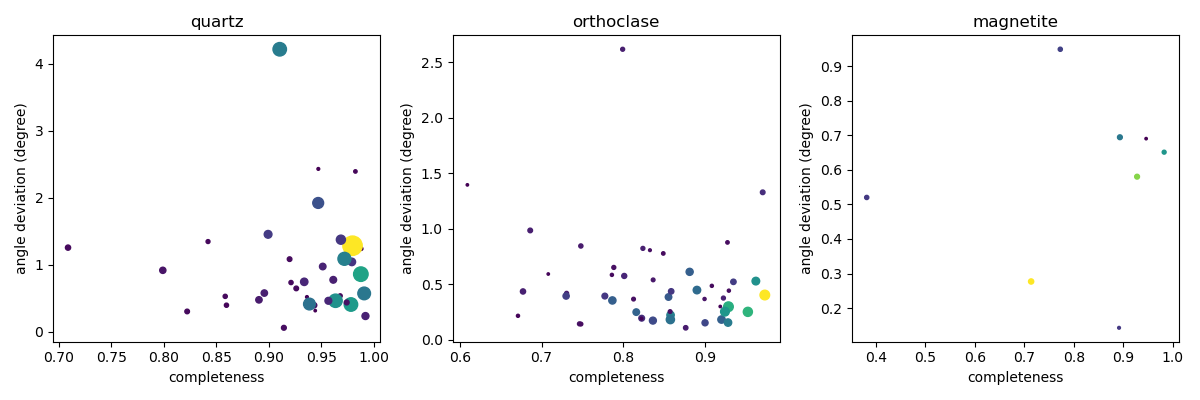

In [82]:
# plot stats per grain
N = len(stats)

fig = pl.figure(figsize=(4*N,4))
for i,(pname,stat) in enumerate(stats.items()):
    ax = fig.add_subplot(1,N,i+1)
    ax.scatter(stat['completeness'], stat['angle deviation'],
           s=xmap.grains.get_all('grainsize', pname),
           c=xmap.grains.get_all('TotalIntensity', pname))
    ax.set(xlabel='completeness', ylabel='angle deviation (degree)')
    ax.set_title(pname)
fig.tight_layout()

Don't forget to save xmap and peakfiles once refinement has been done.

In [83]:
# Once grain ubis have been refined, save files
for xmap,cf in zip(DATA_dict['xmap'], DATA_dict['cf']):
    pkspath = xmap.h5name.replace('xmap', 'pk2d_p_flt_dbsc')
    xmap.save_to_hdf5()
    #utils.colf_to_hdf(cf, pkspath, save_mode='minimal')

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.h5


### Misorientation analysis
This part is similar to `Tutorial_004_Grain_Mapping` with thresholding technique. Compute Misorientation metrics and compare the grain maps obtained with both methods.

In [84]:
# if computing a stack, select one map
xmap = pixelmap.load_from_hdf5(DATA_dict['xmap'][0].h5name)

In [85]:
# GROD: Grain Reference Orientation Deviation 
xmap.calcGROD(pixel_orientation='U')

Computing GROD: 100%|██████████| 94/94 [00:02<00:00, 31.62it/s]


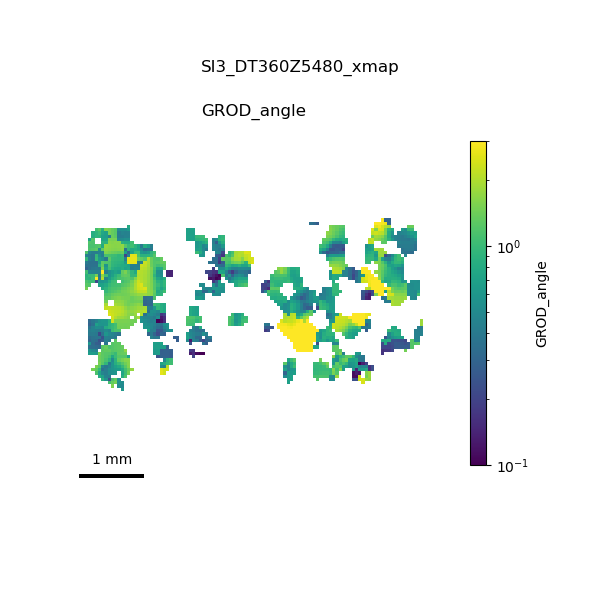

In [86]:
# plot GROD angle. also called "Mis2Mean" in MTex: Hiow much each pixel deviates from its mean grain orientation
norm=pl.matplotlib.colors.LogNorm(vmin=.1, vmax=3)
pl.close('all')

fig = xmap.plot('GROD_angle', norm=norm, out=True)

Large GROD values may be indicative of incomplete grain segmentation, where two grains close in orientation were not separated. If too many of these are present, run again teh DBSCAN segmentation using lower eps. 

The clustering method ignores grain boundaries, but it is possible to compute them with a misorientation thresold and overlap them with the grain map.  

In [87]:
for phase in phase_name_list:
    xmap.calcGrains(phase, threshold_deg=5, min_grain_size=3, update_grain_id=False)

Identified 32 grains for phase 'quartz'
Identified 32 grains for phase 'orthoclase'
Identified 6 grains for phase 'magnetite'


In [89]:
colors = pl.matplotlib.cm.tab10.colors
colors = ['cyan','r','fuchsia']

for i,phase in enumerate(phase_name_list):
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], resolution_factor=2, gb_color=colors[i])

**Kernel Average Misorientation**

We can do the same with kernel average misorientation

In [90]:
# Kernel Average Misorientation
for phase in phase_name_list:
    xmap.calcKAM(phase, Ucol='U', kernel_size=3, threshold_deg=2, use_numba_acceleration=False, mode='mean')

Orix symmetry-accurate mode (slower)...


100%|██████████| 108/108 [00:06<00:00, 16.79it/s]


Orix symmetry-accurate mode (slower)...


100%|██████████| 108/108 [00:06<00:00, 17.04it/s]


Orix symmetry-accurate mode (slower)...


100%|██████████| 108/108 [00:06<00:00, 16.94it/s]


In [91]:
# merge KAM_<phase> maps into a single map
KAM_merged = np.zeros_like(xmap.KAM_quartz)

for phase in phase_name_list:
    if f'KAM_{phase}' in xmap.titles():
        pm = xmap.get_phase_mask(phase)
        KAM_merged[pm] = xmap.get(f'KAM_{phase}')[pm]

xmap.add_data(KAM_merged,'KAM')

# delete former KAM_<phase> arrays
for p in xmap.phases.pnames:
    if f'KAM_{p}' in xmap.titles():
        delattr(xmap, f'KAM_{p}')

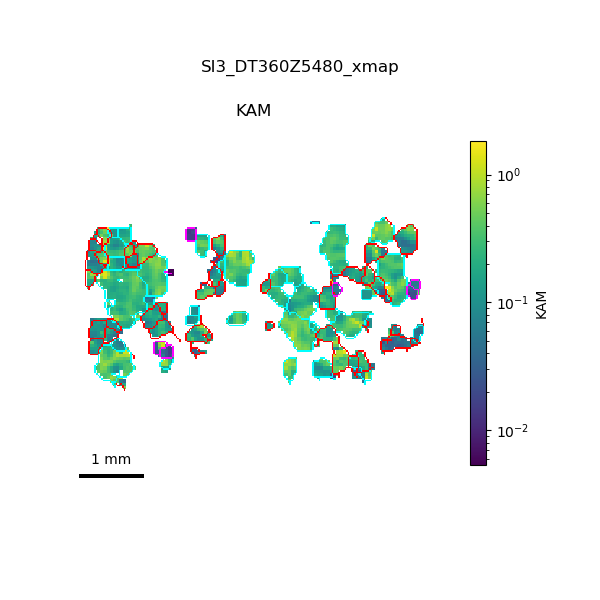

In [92]:
fig = xmap.plot('KAM', norm=pl.matplotlib.colors.LogNorm(), out=True)

for i,phase in enumerate(phase_name_list):
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], resolution_factor=2, gb_color=colors[i])

For comparison we can also plot the `grain_id` map (obtained by clustering) and overlap grain boundaries from thresholding

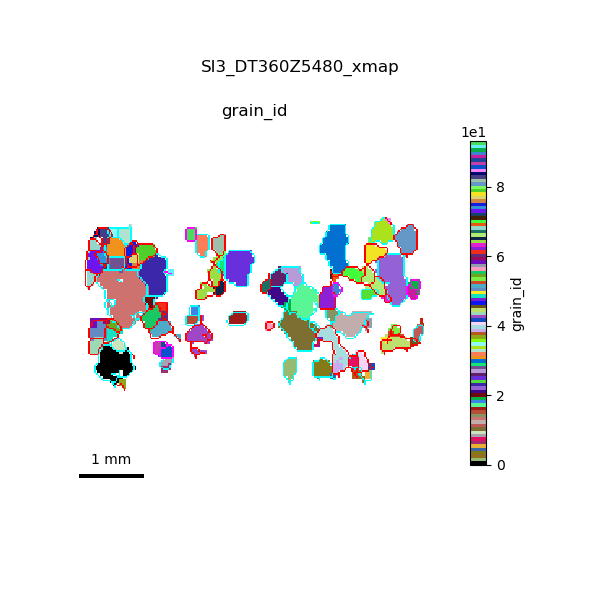

In [93]:
cmap = utils.random_color_map(ncolors = len(np.unique(xmap.grain_id)) - 1)
cmap.set_under('none')

fig = xmap.plot('grain_id', cmap=cmap, vmin=-.01, out=True)

for i,phase in enumerate(phase_name_list):
    xmap.add_grain_boundaries(phase, ax=fig.axes[0], resolution_factor=2, gb_color=colors[i])

### Save
If you want to save KAM / GROD arrays 

In [ ]:
xmap.save_to_hdf5()

### Some notes for map stacks
If working with a 3D map stack, the calcGROD and calcKAM method can be iterated through all maps. 

Note that the grain reference orientation for GROD is the mean orientation refined on the 2D slice, not the mean orientation across the whole 3D volume because each slice is refined individually uising the associated peakfile

For KAM, the 2D map uses a 2D neighborhood. However, it is possible to get the 3D-KAM by stacking all orientation maps in a (Nx,Ny,Nz,3,3) array and computing misorientation on a 3D neighborhood. Not yet implemented in `orientation` module. Maybe in recent MTex updates?